# 학습이 잘 안되는 원인이 gru 첫 context 값을 0으로 넣어서 collapse할수도 있겠다는 생각이 들어 gru context 초기값을 0 대신 인코더 feaature map을 avg pool한 벡터를 projection한 벡터 (이걸 enc context라고 임시 명명) 넣어주는 식으로 차이 준 모델)

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 그동안 imshow할때 aspect="auto"로 했어서 resize shape 관계없이 무조건 정방이미지로 시각화되었는데, resize 어떻게 되었는지 확인할 수 있게 aspect="equal"로 수정하고, 리사이즈 형상에 따라 성능영향차이가 생기는지 실험해보고자 함

In [3]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)



def plot_paired_dataset(hme_images, pme_images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

    assert vocab is not None, "vocab을 입력하세요"

    f = plt.figure(figsize=(figure_width*5, figure_height*2))
    outer = gridspec.GridSpec(grid_height, grid_width, wspace=wspace, hspace=hspace)

    eos_idx = 1
    img_idx = 0

    for i in range(grid_height):
        for j in range(grid_width):
            # === 내부 그리드 (각 셀 안에 1x2 구조) ===
            inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[i * grid_width + j], wspace=wspace, hspace=hspace)

            # --- HME ---
            ax_hme = plt.Subplot(f, inner[0])
            hme_img = hme_images[img_idx].cpu().detach()
            ax_hme.imshow(hme_img.permute(1,2,0).numpy(), cmap='gray', aspect='equal')
            ax_hme.axis('off')
            f.add_subplot(ax_hme)

            # --- PME ---
            ax_pme = plt.Subplot(f, inner[1])
            pme_img = pme_images[img_idx].cpu().detach()
            ax_pme.imshow(pme_img.permute(1,2,0).numpy(), cmap='gray', aspect='equal')
            ax_pme.axis('off')
            f.add_subplot(ax_pme)

            # --- Caption (공통 타이틀) ---
            label = labels[img_idx].cpu().detach().tolist()
            if eos_idx in label:
                label = label[1:label.index(eos_idx)]  # <sos>, <eos> 제거
            label = vocab.decode(label)

            title_color = 'k'
            if y_hats is not None:
                y_hat = y_hats[img_idx].cpu().detach().tolist()
                if eos_idx in y_hat:
                    y_hat = y_hat[:y_hat.index(eos_idx)]
                y_hat = vocab.decode(y_hat)

                if label != y_hat:
                    title_color = 'r'

                label = f'gt: {label}\npred: {y_hat}'

            ax_pme.set_title(label, color=title_color, fontsize=10, pad=10)

            img_idx += 1

    plt.show()


In [4]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [5]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):
    """Loss 곡선 시각화."""

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [6]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)

In [7]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [9]:
import os, json
from datetime import datetime
import torch

epoch = int(input("epoch: "))
patience = int(input("patience: "))
bs = int(input("batch size: "))

CFG = {
  "img_size": (128,128),
  "pad_idx": 112,
  "sos_idx":0,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": "adadelta",
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = input("model_name: ")
scheduler_name = input("scheduler_name: ")
steps = int(input("steps per epoch: "))
min_lr = float(input("min_lr: "))
max_lr = float(input("max_lr: "))

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*epoch*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
scheduler_info["params"] = params_cosineAnnealingWarmupRestarts


CFG["scheduler"] = scheduler_info

epoch: 20
patience: 3
batch size: 16
model_name: DLA (with enc context, 128x128 resize)
scheduler_name: CosineAnnealingWarmup
steps per epoch: 442
min_lr: 1e-5
max_lr: 1e-4


In [10]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/DLA (with enc context, 128x128 resize)_epoch20_patience_3_bs16_scheduler_CosineAnnealingWarmup_minLR_1e-05_maxLR_0.0001/config.json


In [11]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [12]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [13]:
from torchvision import transforms
import torch
from PIL import ImageOps


def paired_collate_fn(batch):
    hme_images = torch.stack([item["image_hme"] for item in batch], dim=0)
    pme_images = torch.stack([item["image_pme"] for item in batch], dim=0)

    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image_hme": hme_images, "image_pme": pme_images, "formula": formulas}


def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [14]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class PairedFormulaDataset(Dataset):
    def __init__(self, train_hme_path, train_pme_path, labels_path, transform, vocab):

        self.transform = transform
        self.vocab = vocab

        self.samples = []
        with open(labels_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) != 2:
                    continue
                file_id, caption = parts

                if '.' not in file_id:
                    file_id = f"{file_id}.png"

                hme_path = os.path.join(train_hme_path, file_id)
                pme_path = os.path.join(train_pme_path, file_id)

                if os.path.exists(hme_path) and os.path.exists(pme_path):
                    self.samples.append((hme_path, pme_path, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        hme_path, pme_path, caption = self.samples[idx]
        hme_img = Image.open(hme_path).convert('L')
        pme_img = Image.open(pme_path).convert('L')

        if self.transform:
            hme_img = self.transform(hme_img)
            pme_img = self.transform(pme_img)

        caption_tokens = self.vocab.encode(caption)
        caption = torch.tensor(caption_tokens, dtype=torch.long)

        return {
            "image_hme": hme_img,
            "image_pme": pme_img,
            "formula": caption
        }


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [15]:
train_hme_path = CFG["data"]["crohme"]["hme_img"]
train_pme_path = CFG["data"]["crohme"]["pme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

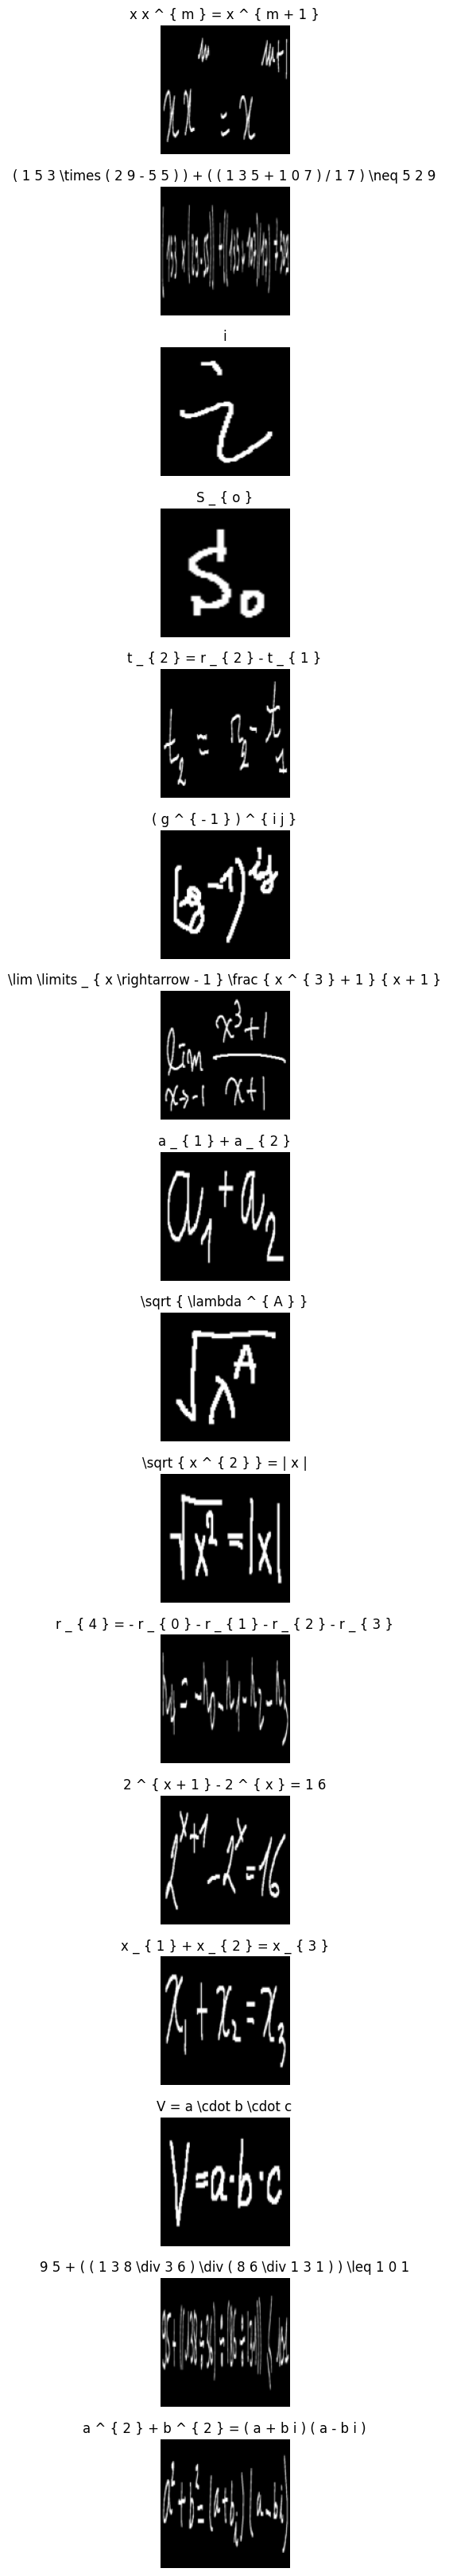

In [16]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = PairedFormulaDataset(train_hme_path, train_pme_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=paired_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=paired_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)
im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)


# 데이터 확인

batch = next(iter(trainloader))
hme_images = batch['image_hme']
pme_images = batch['image_pme']
labels = batch['formula']

plot_dataset(hme_images, labels, grid_width=1, grid_height=16, figure_width=1, figure_height=16, vocab=vocab, wspace=0.25, hspace=0.25)

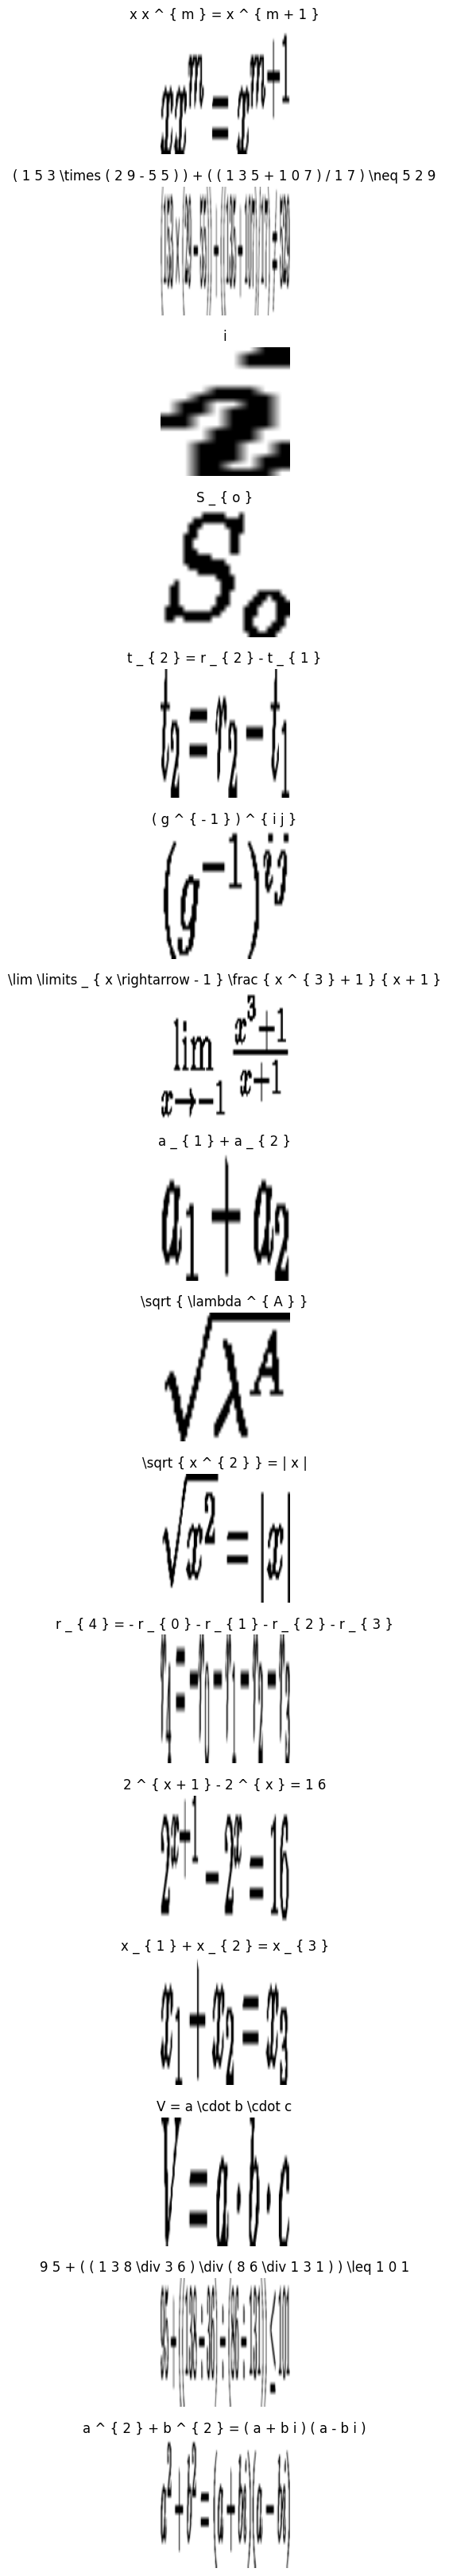

In [17]:
plot_dataset(pme_images, labels, grid_width=1, grid_height=16, figure_width=1, figure_height=16, vocab=vocab, wspace=0.25, hspace=0.25)

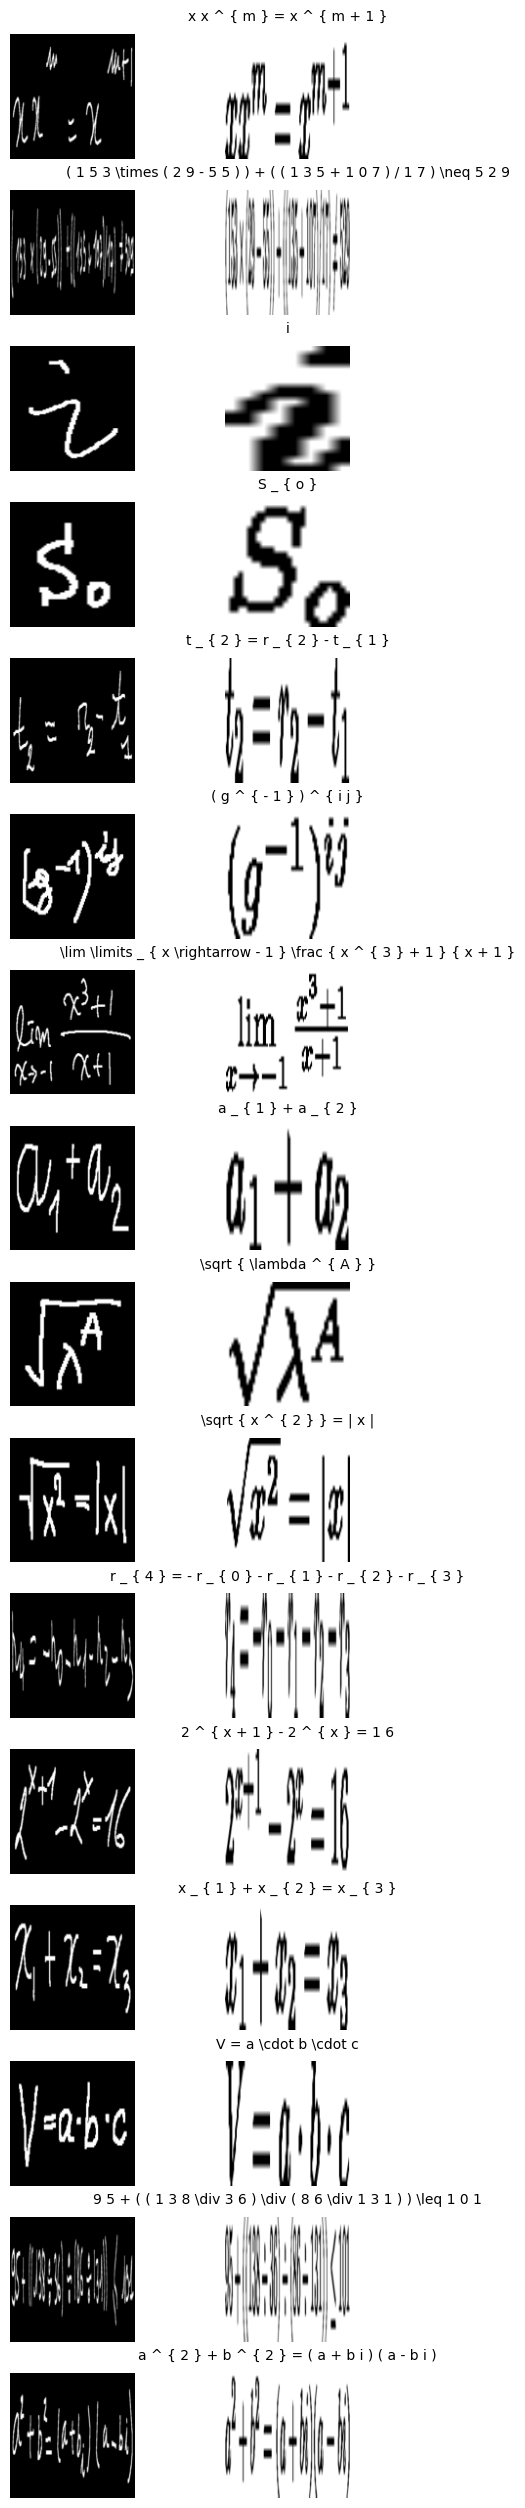

In [18]:
plot_paired_dataset(hme_images, pme_images, labels, grid_width=1, grid_height=16, figure_width=1, figure_height=16, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## Encoder

In [19]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights


class DenseNetEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        densenet = densenet121(weights=None)    # 이번 프로젝트는 imageNet 데이터에 비교하면 수식글씨로, imageNet 가중치가 방해될 수도 있어 사전학습 가중치 없이 불러오는게 유리할수도 있음

        # First conv layer 수정: in_channels=1로 (우리 프로젝트에 맞춰 gpu 메모리 소모 줄이기 위해 그레이스케일로 변환)
        densenet.features.conv0 = nn.Conv2d(
            in_channels=1, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        # Remove classification head
        features = list(densenet.features.children())

        # Use all layers except final norm+relu+avgpool
        self.backbone = nn.Sequential(*features[:-1])

        # 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.backbone(x)                       # (B,1,128,768) -> (B,1024,4,24)
        B, D, _, _ = x.shape
        x = x.reshape(B, D, -1)                    # (B,1024,4*24)
        x = x.transpose(1,2)                       # (B,1024,96) -> (B,96,1024)
        return x


## Decoder

- 일단 단순성 편의상 num_layers는 nn.GRU에서 자동으로 반영하게 하였음, 그러나 이 경우 context 반영은 가장 초기 hidden cell에 대해서만 가능하고, 레이어별로 context 반영하는 등은 부족
- 만약 RNN 구조로 여러 층에서 context 반영하려면 nn.GRU 대신 nn.GRUCell 이용해서 수정하거나 nn.GRU에 (B,1,H) 대신 각 레이어 별 정보를 담아 (B,L,H)로 넘겨주면 되는듯. 그런데 그럴바에 차라리 셀프 어텐션으로 context 반영하게끔 하는 트랜스포머 구조로 만들어버리는게 나을수도?

In [20]:
import torch
import torch.nn as nn

class Decoder(nn.Module):

    def __init__(self, vocab_size, emb_dim_enc=1024, hidden_dim=256, emb_dim_dec=1024, num_layers=1):
        super().__init__()

        self.gru = nn.GRU(emb_dim_enc+emb_dim_dec, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)


        # weight initialization

        # nn.GRU
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, prev_token, hidden, context):

        # prev_token: (B,D_dec)
        # hidden: (B,H)
        # context: (B,D_enc)

        # 지금은 num_layers는 무조건 1이라서 context는 (B,L,H) 대신 (B,1,H), hidden은 (D*L,B,H) 대신 (D,B,H)로 받는다고 생각하고 unsqueeze 등 shape 변경

        prev_token = prev_token.unsqueeze(1)                  # (B,D_dec) -> (B,1,D_dec)
        context = context.unsqueeze(1)                        # (B,D_enc) -> (B,1,D_enc)

        dec_input = torch.cat([prev_token, context], dim=-1)  # (B,1,D_dec+D_enc)

        # nn.GRU에서 요구하는 hidden 형상 (D*L,B,H)가 되도록 변경
        hidden = hidden.unsqueeze(0)

        output, hidden = self.gru(dec_input, hidden)
        output = output.squeeze(1)                       # (B,1,H) -> (B,H)
        hidden = hidden.squeeze(0)                       # (1,B,H) -> (B,H)

        output_logits = self.fc_out(output)             # (B,H) -> (B,V)
        return output_logits, hidden


## Cross Attention

### 변경사항
- 모델에 inference 함수 추가 => top-k, top-p, beam search 등 다양한 방식 inference 코드 작성해보기

In [21]:
# paired한 학습이 아니라 단일 도메인에 대해 돌렸을때 성능 나오는지 확인하기 위해 Paired 없을때 단일도메인 내 인코더-디코더 간 어텐션만 추가해서 구성한 Lite 모델

import torch.nn.functional as F
import random


# 디코더에서 패딩되어 들어오는 gt: (B,T)에서, pad를 제외한 실제 길이에 해당하는 length: (B,)를 구해서 pad부분은 tf 적용하지 않도록 할 떄 이용하는 함수
def get_lengths(labels, eos_id):

    # eos 위치 찾기 (없으면 전부 길이로)
    eos_mask = (labels == eos_id)
    # eos가 처음 등장하는 인덱스
    lengths = eos_mask.float().argmax(dim=1)

    # 만약 eos가 없는 경우 (argmax가 0을 반환) → 전체 길이로 처리
    lengths[lengths == 0] = labels.size(1)

    return lengths


class DLAModel(nn.Module):
    def __init__(self, model_config=None):
        super().__init__()

        # 설정 파라미터 추출
        self.vocab_size = model_config.get("vocab_size", 112)
        self.enc_emb_dim = model_config.get("encoder_emb_dim", 256)
        self.dec_emb_dim = model_config.get("decoder_emb_dim", 256)
        self.dec_hid_dim = model_config.get("decoder_hidden_dim", 512)

        self.embed = nn.Embedding(self.vocab_size, self.dec_emb_dim)

        # 인코더
        self.encoder = DenseNetEncoder()
        self.encoder_proj = nn.Linear(1024, self.enc_emb_dim)
        self.encoder_context_proj = nn.Linear(self.enc_emb_dim, self.dec_hid_dim)

        # 바다나우 어텐션 위한 파라미터
        self.W_enc = nn.Linear(self.enc_emb_dim, self.dec_hid_dim, bias=False)
        self.W_hidden = nn.Linear(self.dec_hid_dim, self.dec_hid_dim, bias=True)
        self.W_coverage = nn.Linear((CFG["img_size"][0]//32) * (CFG["img_size"][1]//32), self.dec_hid_dim, bias=False)
        self.v = nn.Linear(self.dec_hid_dim, 1, bias=False)

        # 디코더
        self.decoder = Decoder(self.vocab_size, self.enc_emb_dim, self.dec_hid_dim, self.dec_emb_dim)


        # weight initialization

        # 임베딩 레이어
        nn.init.uniform_(self.embed.weight, -0.1, 0.1)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, images_hme, images_pme, labels, tf_ratio=CFG["training"]["tf_ratio"]):

        # images: (B,1,128,768)
        # labels: (B,T)

        enc_hme = self.encoder(images_hme)     # (B,96,1024)
        enc_hme = self.encoder_proj(enc_hme)   # (B,96,1024) -> (B,96,D_enc)

        if images_pme is not None:
            enc_pme = self.encoder(images_pme)
            enc_pme = self.encoder_proj(enc_pme)

        B = enc_hme.shape[0]               # batch size

        T = labels.shape[1]            # max_seq_len => <sos>, <eos> 포함

        # HME 디코딩
        dec_out_hme = []
        dec_out_pme = []

        # <sos>
        prev_token_hme = labels[:, 0]             # (B,) - <sos>
        prev_token_hme = self.embed(prev_token_hme)   # (B,) -> (B,D_dec)

        # prev_hidden_hme = torch.zeros((B, self.dec_hid_dim), device=images_hme.device)     # (B,H)
        enc_hme_context = enc_hme.mean(dim=1)  # (B,D_enc)
        prev_hidden_hme = self.encoder_context_proj(enc_hme_context)

        coverage_hme = None

        if images_pme is not None:
            prev_token_pme = labels[:, 0]             # (B,) - <sos>
            prev_token_pme = self.embed(prev_token_pme)   # (B,) -> (B,D_dec)

            # prev_hidden_pme = torch.zeros((B, self.dec_hid_dim), device=images_hme.device)     # (B,H)
            enc_pme_context = enc_pme.mean(dim=1)
            prev_hidden_pme = self.encoder_context_proj(enc_pme_context)

            coverage_pme = None

        length = get_lengths(labels, eos_id=CFG["eos_idx"]) # (B,)

        for t in range(1,T):

            # tf mask
            tf_mask = torch.rand(B, device=images_hme.device) < tf_ratio  # (B,)
            valid_mask = t < length                                   # (B,)
            final_mask = tf_mask & valid_mask                         # (B,)


            # HME
            if coverage_hme is None:
                scores_hme = torch.tanh(self.W_enc(enc_hme) + self.W_hidden(prev_hidden_hme).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)

            elif coverage_hme is not None:
                scores_hme = torch.tanh(self.W_enc(enc_hme) + self.W_hidden(prev_hidden_hme).unsqueeze(1) + self.W_coverage(coverage_hme).unsqueeze(1))

            scores_hme = self.v(scores_hme).squeeze(2)         # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff_hme = F.softmax(scores_hme, dim=-1)     # (B,96)

            if coverage_hme is None:
                coverage_hme = attn_coeff_hme

            elif coverage_hme is not None:
                coverage_hme = coverage_hme + attn_coeff_hme

            context_hme = enc_hme.transpose(1,2) @ attn_coeff_hme.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context_hme = context_hme.squeeze(2)               # (B,D_enc,1) -> (B,D_enc)

            logits_y_hme, cur_hidden_hme = self.decoder(prev_token_hme, prev_hidden_hme, context_hme)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out_hme.append(logits_y_hme)

            # 기본값은 모델 예측 argmax
            prev_token_hme = logits_y_hme.argmax(dim=-1)

            # teacher forcing 적용할 위치는 정답 label로 덮어쓰기
            prev_token_hme[final_mask] = labels[final_mask, t]

            prev_token_hme = self.embed(prev_token_hme)       # (B,) -> (B,D_dec)
            prev_hidden_hme = cur_hidden_hme


            # PME
            if images_pme is not None:
                if coverage_pme is None:
                    scores_pme = torch.tanh(self.W_enc(enc_pme) + self.W_hidden(prev_hidden_pme).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)

                elif coverage_pme is not None:
                    scores_pme = torch.tanh(self.W_enc(enc_pme) + self.W_hidden(prev_hidden_pme).unsqueeze(1) + self.W_coverage(coverage_pme).unsqueeze(1))

                scores_pme = self.v(scores_pme).squeeze(2)         # (B,96,H) -> (B,96,1) -> (B,96)
                attn_coeff_pme = F.softmax(scores_pme, dim=-1)     # (B,96)

                if coverage_pme is None:
                    coverage_pme = attn_coeff_pme

                elif coverage_pme is not None:
                    coverage_pme = coverage_pme + attn_coeff_pme

                context_pme = enc_pme.transpose(1,2) @ attn_coeff_pme.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
                context_pme = context_pme.squeeze(2)               # (B,D_enc,1) -> (B,D_enc)

                logits_y_pme, cur_hidden_pme = self.decoder(prev_token_pme, prev_hidden_pme, context_pme)    # logits_y: (B,V), cur_hidden: (B,H)
                dec_out_pme.append(logits_y_pme)

                # 기본값은 모델 예측 argmax
                prev_token_pme = logits_y_pme.argmax(dim=-1)

                # teacher forcing 적용할 위치는 정답 label로 덮어쓰기
                prev_token_pme[final_mask] = labels[final_mask, t]

                prev_token_pme = self.embed(prev_token_pme)       # (B,) -> (B,D_dec)
                prev_hidden_pme = cur_hidden_pme


        dec_out_hme = torch.stack(dec_out_hme)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out_hme = dec_out_hme.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        if images_pme is None:
            return dec_out_hme, None, None, None

        else:
            dec_out_pme = torch.stack(dec_out_pme)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
            dec_out_pme = dec_out_pme.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

            return dec_out_hme, dec_out_pme, enc_hme, enc_pme


    def inference(self, images, max_seq_len):

        # images: (B,1,128,768)

        enc = self.encoder(images)     # (B,96,D_enc)
        enc = self.encoder_proj(enc)   # (B,96,1024) -> (B,96,D_enc)

        B = enc.shape[0]               # batch size

        # PME 디코딩
        dec_out = []

        # <sos>
        prev_token = torch.zeros(B, dtype=torch.long, device=images.device)         # (B,) - <sos>
        prev_token = self.embed(prev_token)                                        # (B,) -> (B,D_dec)

        prev_hidden = torch.zeros((B, self.dec_hid_dim), device=images.device)     # (B,H)

        coverage = None

        for t in range(1,max_seq_len):

            if coverage is None:
                scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)

            elif coverage is not None:
                scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1) + self.W_coverage(coverage).unsqueeze(1))

            scores = self.v(scores).squeeze(2)        # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff = F.softmax(scores, dim=-1)   # (B,96)

            if coverage is None:
                coverage = attn_coeff

            elif coverage is not None:
                coverage = coverage + attn_coeff

            context = enc.transpose(1,2) @ attn_coeff.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context = context.squeeze(2)               # (B,D_enc,1) -> (B,D_enc) == (B,D_enc)

            logits_y, cur_hidden = self.decoder(prev_token, prev_hidden, context)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out.append(logits_y)

            # inference 시점이므로 teacher forcing 적용하지 않음
            prev_token = logits_y.argmax(dim=-1)  # (B,V) -> (B,)

            prev_token = self.embed(prev_token)       # (B,) -> (B,D_dec)
            prev_hidden = cur_hidden


        dec_out = torch.stack(dec_out)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out = dec_out.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        return dec_out

# Train

- 변경사항: scheduler 하이퍼파라미터 오버핏 방지되고 안정적으로 수렴하도록 학습하는 에포크랑 스텝 수 고려해서 재설정
    - PairedDataset에 맞도록 수정 및 optimizer.zero_grad()위치 등 자잘한 디테일도 수정
-  학습도중 강제로 셀 스탑해도 log_dict, best_loss 반환하도록 수정

In [22]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    matching_criterion = nn.MSELoss()
    match_weight = CFG["training"]["match_weight"]

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs_hme = batch["image_hme"].to(device)
                imgs_pme = batch["image_pme"].to(device)
                labels = batch["formula"].to(device)

                dec_out_hme, dec_out_pme, enc_hme, enc_pme = model(imgs_hme, imgs_pme, labels)  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss_hme = criterion(dec_out_hme.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                loss_pme = criterion(dec_out_pme.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                loss_context = matching_criterion(enc_hme.mean(1), enc_pme.mean(1))
                loss = loss_hme + loss_pme + match_weight * loss_context

                pred_tokens = dec_out_hme.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs_hme = batch["image_hme"].to(device)
                imgs_pme = None
                labels = batch["formula"].to(device)
                pred, _, _, _ = model(imgs_hme, imgs_pme, labels)  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)


                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })


            torch.save({"model": model.state_dict()}, save_last)


            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping Count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [23]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [23]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [24]:
import os, json, random
from pathlib import Path
from datetime import datetime

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = DLAModel(model_config=CFG["model"]).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()
if opt_name == "adam":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


# Learning rate 스케쥴러

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = CosineAnnealingWarmupRestarts(optimizer,
                 first_cycle_steps=params_cosineAnnealingWarmupRestarts["first_cycle_steps"],
                 cycle_mult=params_cosineAnnealingWarmupRestarts["cycle_mult"],
                 max_lr=params_cosineAnnealingWarmupRestarts["max_lr"],
                 min_lr=params_cosineAnnealingWarmupRestarts["min_lr"],
                 warmup_steps=params_cosineAnnealingWarmupRestarts["warmup_steps"],
                 gamma=params_cosineAnnealingWarmupRestarts["gamma"])


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/20: 100%|██████████| 442/442 [2:39:28<00:00, 21.65s/it, expr0=0, expr1=0, expr2=0, expr3=0, loss=9.76, lr=5.49e-5, wer=3.86]



[Train Epoch 1] Loss: 9.7650, Expr@0: 0.0000, Expr@1: 0.0000, Expr@2: 0.0001, Expr@3: 0.0001, WER: 7.2119


[Valid] Epoch 1/20: 100%|██████████| 1767/1767 [39:27<00:00,  1.34s/it, expr0=0, expr1=0, expr2=0, expr3=0, loss=6.24, wer=1]



[Valid Epoch 1] Loss: 6.4196, Expr@0: 0.0000, Expr@1: 0.0006, Expr@2: 0.0441, Expr@3: 0.0764, WER: 1.1414
Best model saved.



[Train] Epoch 2/20: 100%|██████████| 442/442 [03:18<00:00,  2.23it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=9.54, lr=9.99e-5, wer=8.57]


...


[Valid Epoch 4] Loss: 5.7689, Expr@0: 0.0000, Expr@1: 0.0006, Expr@2: 0.0441, Expr@3: 0.0753, WER: 1.1428
Early Stopping Count: 2/3



[Train] Epoch 5/20: 100%|██████████| 442/442 [03:18<00:00,  2.22it/s, expr0=0, expr1=0, expr2=0, expr3=0.0909, loss=9.33, lr=9.4e-5, wer=7.68]



[Train Epoch 5] Loss: 9.2130, Expr@0: 0.0000, Expr@1: 0.0007, Expr@2: 0.0049, Expr@3: 0.0091, WER: 6.7633


[Valid] Epoch 5/20: 100%|██████████| 1767/1767 [01:26<00:00, 20.40it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.49, wer=1.01]



[Valid Epoch 5] Loss: 5.8089, Expr@0: 0.0000, Expr@1: 0.0006, Expr@2: 0.0441, Expr@3: 0.0770, WER: 1.1394
Early Stopping Count: 3/3
Early stopping at epoch 5


In [25]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/DLA (with enc context, 128x128 resize)_epoch20_patience_3_bs16_scheduler_CosineAnnealingWarmup_minLR_1e-05_maxLR_0.0001/train_log.json


In [26]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

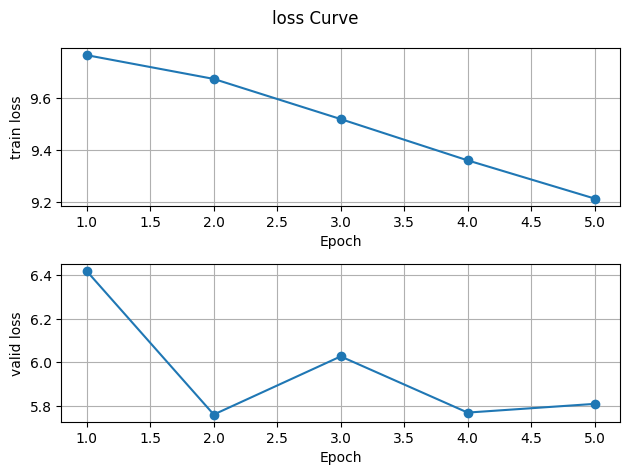

In [27]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

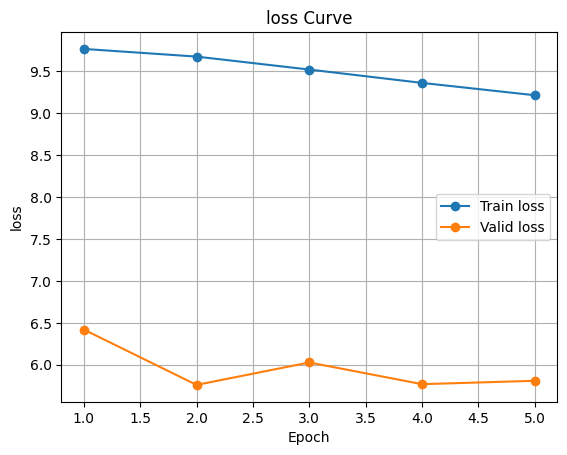

In [28]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

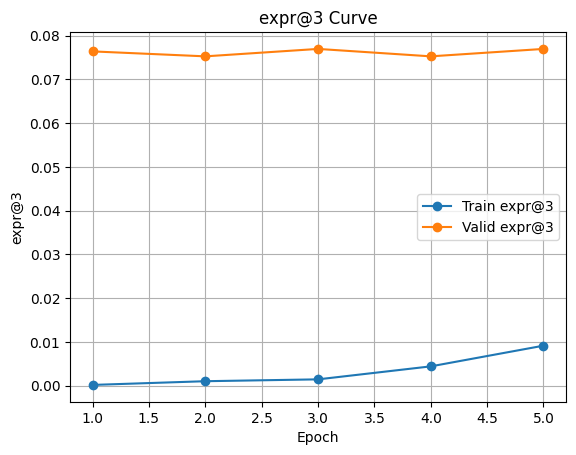

In [29]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

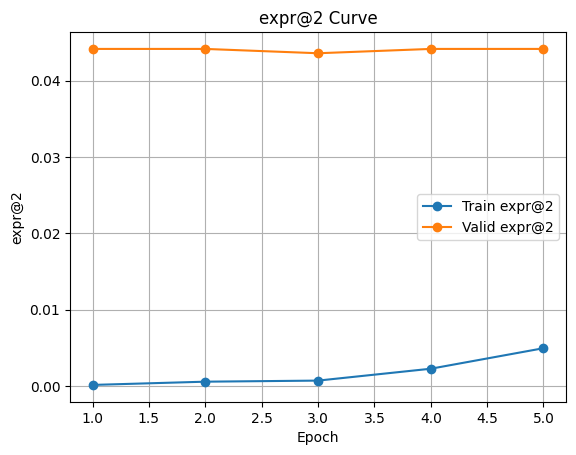

In [30]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

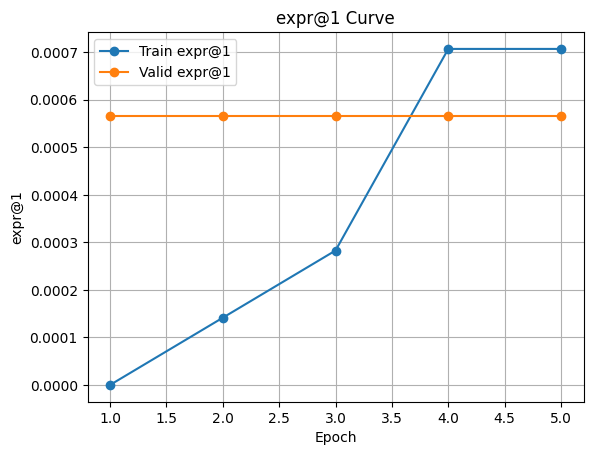

In [31]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

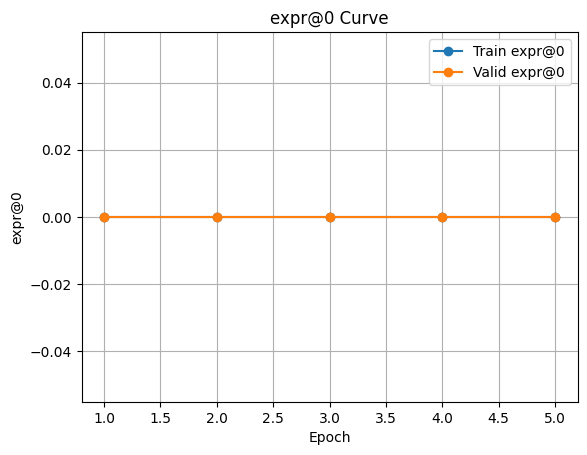

In [32]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

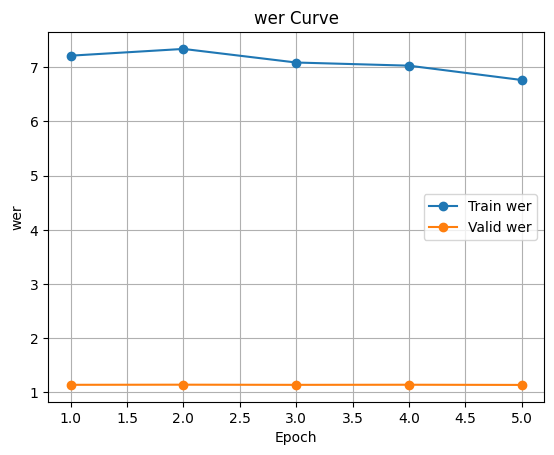

In [33]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

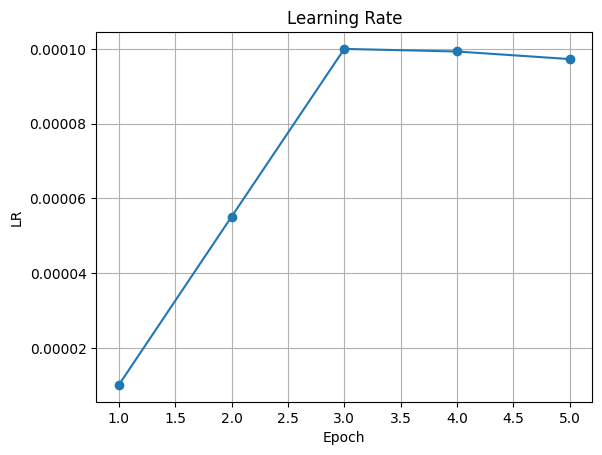

In [34]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [24]:
# testloader는 PairedFormulaDataset이 아니라 FormulaDataset으로 구성되어있다고 가정 => batch["image_hme"] 혹은 batch["image_pme"] 대신 batch["image"]로 이미지 가져옴

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs_hme = batch["image"].to(device)
        imgs_pme = None
        labels = batch["formula"].to(device)
        pred, _, _, _ = model(imgs_hme, imgs_pme, labels)  # (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [25]:
# best_model.pth 가져오기

model = DLAModel(model_config=CFG["model"]).to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [ ]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [11:30<00:00,  1.43it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.54, wer=1]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [13:23<00:00,  1.43it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.71, wer=1.01]


CROHME_2019


...

[Test] batch:985/986: 100%|██████████| 986/986 [10:16<00:00,  1.60it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.67, wer=1]


CROPME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [12:08<00:00,  1.57it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.03, wer=1]


CROPME_2019


[Test] batch:457/1199:  38%|███▊      | 458/1199 [04:56<07:47,  1.59it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.85, wer=1.07]

# Prediction 샘플 시각화

In [ ]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image_hme'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image_pme'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.inference(images, max_seq_len=150)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

## 디버깅

- exprate 계산 시, 단순히 @k로 해버리면 우연히 토큰길이가 k보다 작으면 아예 예측을 이상하게 해도 맞다고 처리해버리는 문제 발견 => 이 부분 개선하도록 메트릭 수정 및 캐글이나 네이버부스트코스  자료 등 코드에는 이 부분 처리하도록 되어있는지 확인할 것
- 논문에서처럼 학습의 어떤 부분이 이미지의 어떤 부분을 참고하고 있는지 시각화해서 xAI방법에서 디버깅해보기 -> 잘 학습되고 있는지,,, (WAP 논문 시각화를 직접 해보는 느낌)
- 128*768로 resize해서 시작 안하고 128x128에서부터 시작해보기? (지푸라기라도 잡는 심정)
- 어떻게 추가할지는 모르겠지만,정칙화 텀을 추가해보기?
- 그래도 안되면 기본 방법은 어느정도 예측 잘할때까지 학습하려면 기본적으로 에포크 너무많이 필요해서 그런거라고 생각하고 트랜스포머 기반으로 바로 적용 시도하는걸로 넘어가기, 트랜스포머 기반으로 두 도메인 이용할 수 있도록 고민해보기)
- dla나 wap에서 어텐션 이외에 추가적으로 도입했던, 내가 구현할때 미처 반영하지 못한 부분 있으면 반영해서 다시 수정해보기

# Next Step
- DLA_single 노트북의 validation, test 함수 부분 model.inference로 y_hat 구하는 걸로 수정
- 어텐션, metric learning 등 시각화
- rendered images (unpaired)도 들어오는 경우 처리하는 코드 작성
- wap pth 파일 로드할 수 있게 모델 따라해서 구현
    - 아니면 self attention이나 mdlstm, cbam, non local block 등 인코더 내에서 contextualize하는 모듈 추가했을때 같은 에포크로 돌릴때 성능이 에포크별로 얼마나 더 좋아지나, 학습이 잘되나 확인??
- PAL, 트랜스포머 이용 모델 (캐글 참고) 성능 확인
- segmentation 기반 아이디어 구현 및 실험
- DA, DG 공부 <br><br>

- dla_single 구현에서 바다나우 어텐션 적용 시 쿼리를 디코더 인풋으로 삼았던 것 같은데, hidden state라고 생각해서 수정해보기 + coverage attention 철학도 반영해서 수정해보기?
- cosineAnnealingWarmup 의 첫 warmup 단계를 조금 덜 급하게 수정? (ex 0.1 -> 0.01, 주기를 줄이거나 늘리기, 주기 돌때마다 학습률 값을 특정 비율로 감소시키는 등)
- 지금 hme, pme pair가 반드시 각 이미지 패치가 와넌 서로 동일한 부분 나타내는거 아닌데도 mse로 비교하는게 좋은 접근법일까? receptive field가 확장되어있기에 괜찮다고 보는건가?
- 캐글에 우리 데이터셋 올리고 아예 대회처럼 만들어보기?

<br><br>
- Densenet 내부 구현 디테일 공부해보기 -> WAP, DLA, PAL논문 읽으며 인코더 디테일 구조 다시한번 체크해보기
- 트랜스포머 구조 적용할때 gradscaler, fp16 autocast 고려해보기?
- beamsearch, top-k, top-p 등 다른 디코딩 (inference) 방법 적용
- 현재 service account api 토큰 때문에 github private로 해둠 -> service account api를 env등으로 암호화 및 gitignore에 추가한 후 public으로 github 폴더 visibility 변경해두기

<br><br>
- 옵션
    - 바다나우 어텐션 대신 루옹 어텐션 적용 (소연 코드 참고)


# 교수님께 문의할 내용

- 자원 제한으로 에포크 충분히 못돌리는거 어떻게 대처? 그 탓에 실험결과를 제대로 비교 불가능...
- cosine annealing warmup scheduler 하이퍼파라미터 찾는 추천 방법?
- 아이디어 어떻게 평가하시는지, 주관적 평가

<br><br>
- 네이버부스트코스 대회 수상팀 깃허브 소유자들에게 자문드려보는것도 괜찮을지도...